# Librerias

In [1]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Carga de la bbdd y reducción

## 1. Cargar csv

In [2]:
#cargar datos
df = pd.read_parquet("../../data/df_limpiado_260504.parquet")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
0,59,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042.0,1,NaN,0,sin_campania_previa,yes,0
1,56,administration,married,secondary,no,45,no,no,unknown,5,may,1467.0,1,NaN,0,sin_campania_previa,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389.0,1,NaN,0,sin_campania_previa,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579.0,1,NaN,0,sin_campania_previa,yes,0
4,54,administration,married,tertiary,no,184,no,no,unknown,5,may,673.0,2,NaN,0,sin_campania_previa,yes,0


In [3]:
#Nos quedamos con las variables que usaremos para perfil de cliente
cols = ["age", "job", "marital", "education", "balance", "default", "housing", "loan", "deposit"]

df_perfil = df[cols].copy()
df_perfil.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  string
 2   marital    11162 non-null  string
 3   education  11162 non-null  string
 4   balance    11162 non-null  int64 
 5   default    11162 non-null  string
 6   housing    11162 non-null  string
 7   loan       11162 non-null  string
 8   deposit    11162 non-null  string
dtypes: int64(2), string(7)
memory usage: 1.1 MB


# 2. Categorizar edad

In [4]:
df_perfil["age_group"] = pd.cut(df_perfil["age"], bins=[0, 25, 35, 45, 55, 65, 120], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])

#Eliminamos la columna numérica original
df_perfil = df_perfil.drop(columns=["age"])

# 3. Categorizar multiproducto

In [5]:
#Crear variables binarias 0/1 para cada producto
df_perfil = df_perfil.copy()

df_perfil["deposit_bin"] = (df_perfil["deposit"] == "yes").astype(int)
df_perfil["loan_bin"] = (df_perfil["loan"] == "yes").astype(int)
df_perfil["housing_bin"] = (df_perfil["housing"] == "yes").astype(int)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1


In [6]:
#Crear variable combinación, según orden de 0 y 1 se puede saber que productos
def multiproducto(row):
    return f"{row['deposit_bin']}{row['loan_bin']}{row['housing_bin']}"

df_perfil["multiproducto"] = df_perfil.apply(multiproducto, axis=1)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101


In [7]:
#Crear columna catagorica de multiproducto:
etiquetas = {
    "000": "Ningún producto",
    "100": "Solo depósitos",
    "010": "Solo préstamos",
    "001": "Solo hipotecas",
    "110": "Depósitos y préstamos",
    "101": "Depósitos y hipotecas",
    "011": "Préstamos y hipotecas",
    "111": "Todos los productos"
}

df_perfil['multiproducto_cat'] = df_perfil['multiproducto'].astype(str).map(etiquetas)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto,multiproducto_cat
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101,Depósitos y hipotecas
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100,Solo depósitos
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101,Depósitos y hipotecas


In [8]:
#Crear columna conteo de productos:
df_perfil["cantidad_prod"] = df_perfil["deposit_bin"] + df_perfil["loan_bin"] + df_perfil["housing_bin"]

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto,multiproducto_cat,cantidad_prod
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101,Depósitos y hipotecas,2
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100,Solo depósitos,1
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101,Depósitos y hipotecas,2


In [9]:
#Crear columna multiproducto binaria:
df_perfil["multiproducto_bin"] = (df_perfil["cantidad_prod"] > 1).astype(int)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto,multiproducto_cat,cantidad_prod,multiproducto_bin
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101,Depósitos y hipotecas,2,1
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100,Solo depósitos,1,0
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101,Depósitos y hipotecas,2,1


# 4. Clústering

In [10]:
#dataset para modelo:
cols_modelo = ["age_group", "job", "marital", "education"]
df_perfil_m = df_perfil[cols_modelo].copy()
data_model = df_perfil_m.copy()
X = data_model.to_numpy()

#Entrenar modelo:
k_opt = 5
km = KModes(n_clusters=k_opt, init='Cao', n_init=5, verbose=0)
clusters = km.fit_predict(X)

#Añadir columna clúster a dataset original:
df_perfil["cluster"] = clusters
df_perfil["cluster"].value_counts().sort_index()

cluster
0    5641
1    1781
2    1233
3    1014
4    1493
Name: count, dtype: int64

In [11]:
#Centroides:
centroides = km.cluster_centroids_
centroides

array([['26-35', 'management', 'married', 'secondary'],
       ['36-45', 'technician', 'single', 'tertiary'],
       ['46-55', 'technician', 'married', 'tertiary'],
       ['46-55', 'administration', 'single', 'secondary'],
       ['36-45', 'blue-collar', 'married', 'primary']], dtype='<U14')

In [12]:
# Moda por clúster
multiproducto_moda = (
    df_perfil.groupby("cluster")["multiproducto_cat"]
    .agg(lambda x: x.mode().iloc[0])
    .sort_index()
)

# Centroides del modelo
perfil_clusters = pd.DataFrame(
    km.cluster_centroids_,
    columns=cols_modelo,
    index=[f"Cluster {i}" for i in range(km.n_clusters)]
)

# Añadir moda
perfil_clusters["multiproducto_moda"] = multiproducto_moda.values

perfil_clusters

,age_group,job,marital,education,multiproducto_moda
Cluster 0,26-35,management,married,secondary,Solo depósitos
Cluster 1,36-45,technician,single,tertiary,Solo depósitos
Cluster 2,46-55,technician,married,tertiary,Solo depósitos
Cluster 3,46-55,administration,single,secondary,Solo depósitos
Cluster 4,36-45,blue-collar,married,primary,Solo hipotecas


In [13]:
#Nos quedamos con variables para estudiar productos
cols_prod = ["cluster", "age_group", "job", "marital", "education", "balance","deposit", "loan", "housing", "default", "multiproducto", "multiproducto_cat", "cantidad_prod", "multiproducto_bin"]

df_product = df_perfil[cols_prod].copy()

df_product.head(3)

,cluster,age_group,job,marital,education,balance,deposit,loan,housing,default,multiproducto,multiproducto_cat,cantidad_prod,multiproducto_bin
0,0,56-65,administration,married,secondary,2343,yes,no,yes,no,101,Depósitos y hipotecas,2,1
1,0,56-65,administration,married,secondary,45,yes,no,no,no,100,Solo depósitos,1,0
2,0,36-45,technician,married,secondary,1270,yes,no,yes,no,101,Depósitos y hipotecas,2,1


# 5. Análisis descriptivo

In [14]:
# Tabla de contingencia Clúster vs Multiproducto
resumen = pd.crosstab(df_perfil['cluster'], df_perfil['multiproducto_bin'], normalize='index') * 100
resumen


multiproducto_bin,0,1
cluster,,
0,74.703067,25.296933
1,76.530039,23.469961
2,80.859692,19.140308
3,72.485207,27.514793
4,75.619558,24.380442


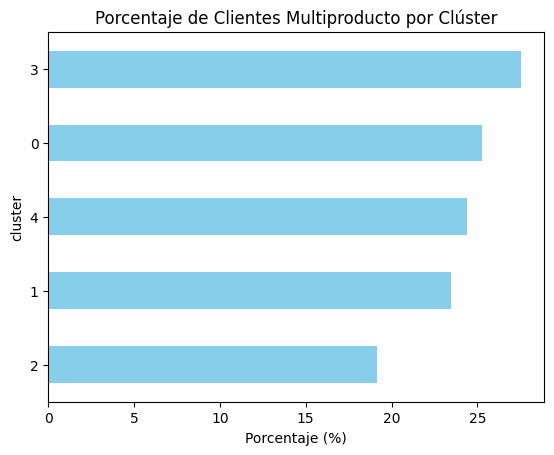

In [15]:
resumen[1].sort_values().plot(kind='barh', color='skyblue')
plt.title('Porcentaje de Clientes Multiproducto por Clúster')
plt.xlabel('Porcentaje (%)')
plt.show()

In [16]:
tabla = pd.crosstab(df_product['age_group'], df_product['multiproducto_bin'])
chi2, p, dof, expected = chi2_contingency(tabla)
print(p)

4.0609687058193257e-35


## Vision general

In [17]:

#Estadística descriptiva de la cantidad de productos
print("--- Estadísticas de Cantidad de Productos ---")
print(df_perfil['cantidad_prod'].describe())

# Media de productos por grupo de edad (Opcional pero muy útil)
print("\n--- Media de productos por Rango de Edad ---")
print(df_perfil.groupby('age_group')['cantidad_prod'].mean().sort_values(ascending=False))

--- Estadísticas de Cantidad de Productos ---
count    11162.000000
mean         1.077764
std          0.706600
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: cantidad_prod, dtype: float64

--- Media de productos por Rango de Edad ---
age_group
26-35    1.148724
<=25     1.124722
36-45    1.106262
46-55    0.998137
56-65    0.959484
65+      0.851759
Name: cantidad_prod, dtype: float64


C:\Users\misab\AppData\Local\Temp\ipykernel_21572\694409197.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')


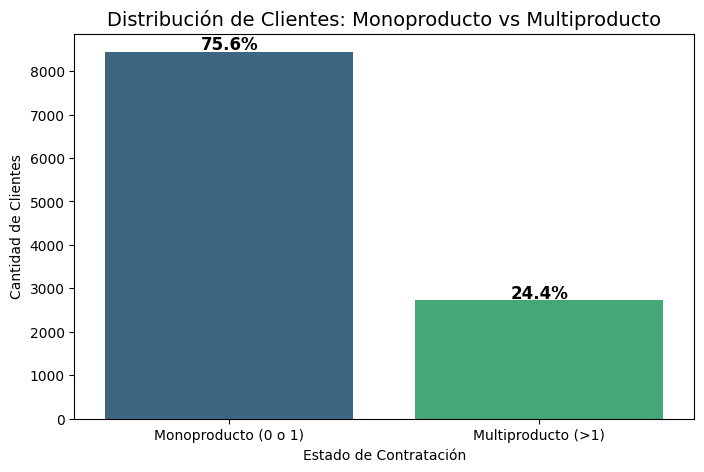

In [18]:
# Distribución de Multiproducto (Binario)
counts = df_perfil['multiproducto_bin'].value_counts()
percentages = df_perfil['multiproducto_bin'].value_counts(normalize=True) * 100

# gráfico de barras
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')

for i, p in enumerate(percentages):
    ax.annotate(f'{p:.1f}%', (i, counts.values[i] + 50), ha='center', fontsize=12, fontweight='bold')

plt.title('Distribución de Clientes: Monoproducto vs Multiproducto', fontsize=14)
plt.xticks([0, 1], ['Monoproducto (0 o 1)', 'Multiproducto (>1)'])
plt.ylabel('Cantidad de Clientes')
plt.xlabel('Estado de Contratación')
plt.show()


## Análisis por combinaciones

C:\Users\misab\AppData\Local\Temp\ipykernel_21572\2048565418.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


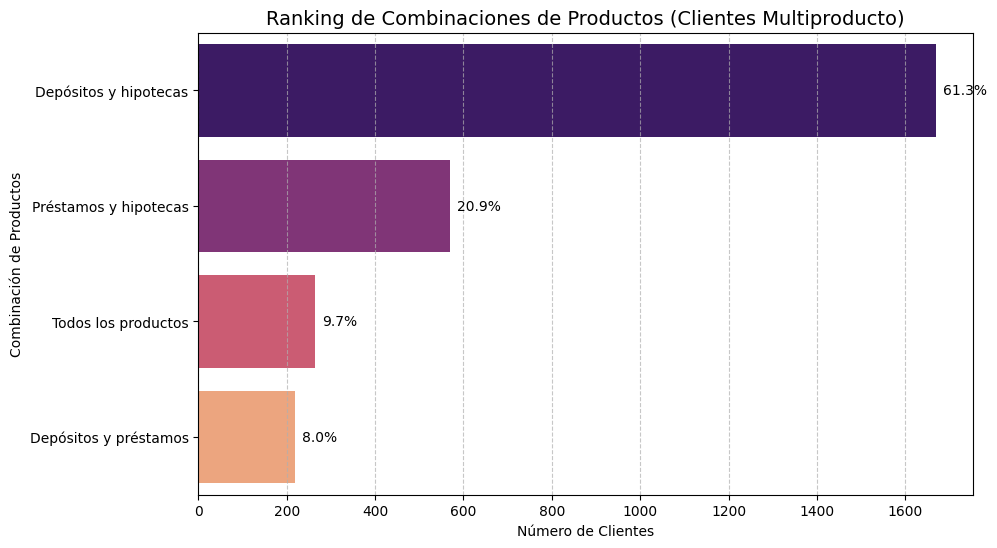

--- Detalle de Combinaciones ---
multiproducto_cat
Depósitos y hipotecas    1670
Préstamos y hipotecas     570
Todos los productos       265
Depósitos y préstamos     219
Name: count, dtype: int64


In [19]:
# 1. Filtrar solo a los clientes multiproducto para ver qué combinaciones tienen
df_multipro = df_perfil[df_perfil['multiproducto_bin'] == 1]

# 2. Conteo de combinaciones (usando la columna que ya creaste)
combinaciones_counts = df_multipro['multiproducto_cat'].value_counts()
combinaciones_percent = df_multipro['multiproducto_cat'].value_counts(normalize=True) * 100

# 3. Visualización de las combinaciones más frecuentes
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=combinaciones_counts.values, 
    y=combinaciones_counts.index, 
    palette='magma'
)

# Añadir etiquetas de porcentaje al final de cada barra
for i, p in enumerate(combinaciones_percent):
    ax.annotate(f'{p:.1f}%', (combinaciones_counts.values[i], i), 
                va='center', xytext=(5, 0), textcoords='offset points')

plt.title('Ranking de Combinaciones de Productos (Clientes Multiproducto)', fontsize=14)
plt.xlabel('Número de Clientes')
plt.ylabel('Combinación de Productos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Tabla de resumen para el informe
print("--- Detalle de Combinaciones ---")
print(combinaciones_counts)

 ## Clúster vs multiproducto

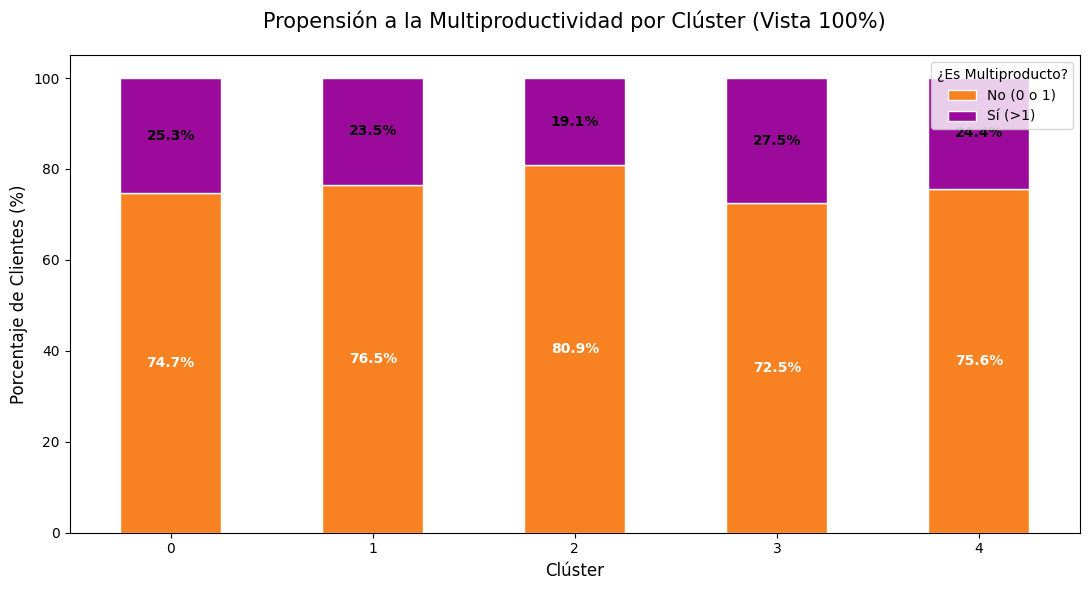

In [20]:
cross_tab = pd.crosstab(df_perfil['cluster'], df_perfil['multiproducto_bin'], normalize='index') * 100

# 2. Graficar barras apiladas
ax = cross_tab.plot(kind='bar', 
                    stacked=True, 
                    figsize=(11, 6), 
                    color=["#f88221", "#9C0A9C"], # Gris para monoproducto, Verde para multiproducto
                    edgecolor='white')


plt.title('Propensión a la Multiproductividad por Clúster (Vista 100%)', fontsize=15, pad=20)
plt.legend(title='¿Es Multiproducto?', labels=['No (0 o 1)', 'Sí (>1)'], loc='upper right')
plt.xlabel('Clúster', fontsize=12)
plt.ylabel('Porcentaje de Clientes (%)', fontsize=12)
plt.xticks(rotation=0)


for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Solo poner etiqueta si el segmento es lo suficientemente grande
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white' if height > 50 else 'black',
                fontweight='bold')

plt.tight_layout()
plt.show()

## Análisis individual

C:\Users\misab\AppData\Local\Temp\ipykernel_21572\3047257535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')
C:\Users\misab\AppData\Local\Temp\ipykernel_21572\3047257535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')
C:\Users\misab\AppData\Local\Temp\ipykernel_21572\3047257535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')


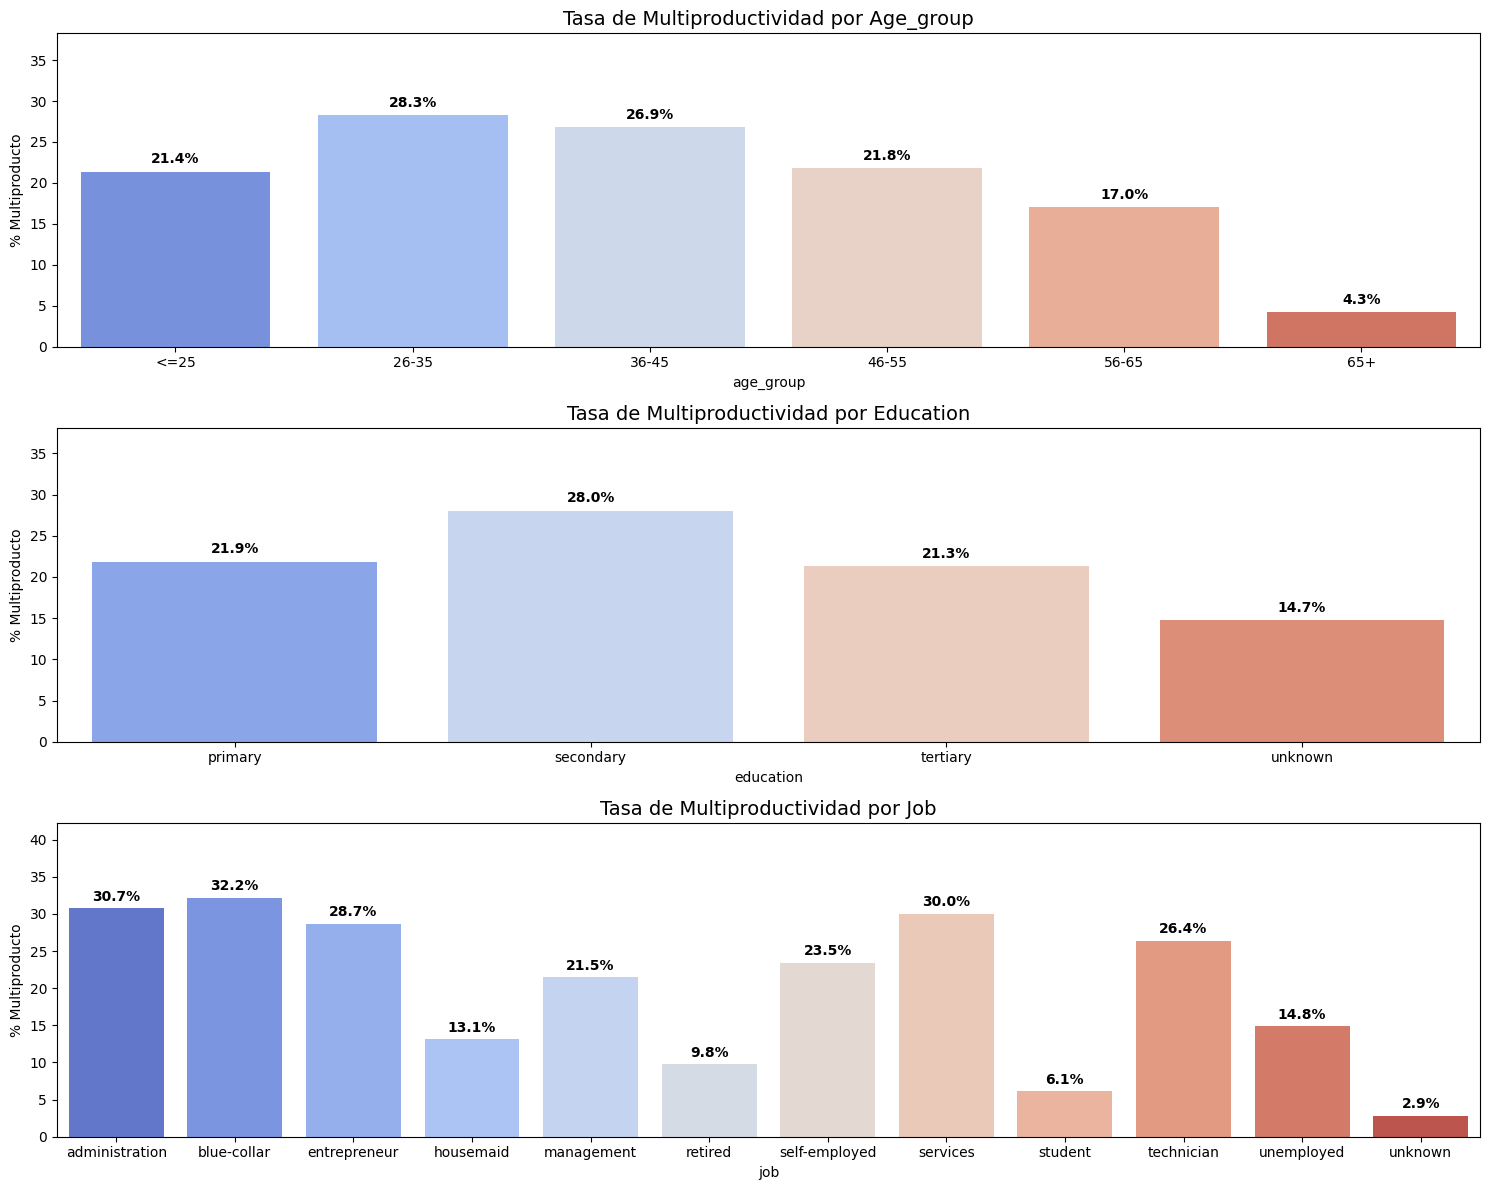

In [21]:
# Lista de variables demográficas a analizar
variables_demo = ['age_group', 'education', 'job']

plt.figure(figsize=(15, 12))

for i, var in enumerate(variables_demo, 1):
    # Crear tabla de contingencia normalizada por variable
    tabla_var = pd.crosstab(df_perfil[var], df_perfil['multiproducto_bin'], normalize='index') * 100
    
    # Crear subgráfico
    plt.subplot(3, 1, i)
    # Graficamos solo la columna '1' (quienes sí son multiproducto)
    sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')
    
    # Personalización
    plt.title(f'Tasa de Multiproductividad por {var.capitalize()}', fontsize=14)
    plt.ylabel('% Multiproducto')
    plt.xlabel(var)
    plt.ylim(0, max(tabla_var[1]) + 10) # Espacio para etiquetas
    
    # Añadir valores sobre las barras
    for index, value in enumerate(tabla_var[1]):
        plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Regresión logística binaria

In [22]:
#ver colinealidad variables:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

categorical_vars = ['age_group', 'education', 'job', 'marital']

cramer_matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars)

for col1 in categorical_vars:
    for col2 in categorical_vars:
        cramer_matrix.loc[col1, col2] = cramers_v(df_perfil[col1], df_perfil[col2])

print(cramer_matrix)


          age_group education       job   marital
age_group       1.0  0.157848  0.378213  0.353281
education  0.157848       1.0  0.462541  0.123964
job        0.378213  0.462541       1.0  0.234958
marital    0.353281  0.123964  0.234958       1.0


Eliminar del modelo job por posible colinealidad y muchas categorías

In [ ]:
'''# MODELO OPCIÓN 1: Reordenar categorías para que perfil profesionales consolidados sea la referencia

#Categoría del balance:
df_perfil['balance_bin'] = pd.qcut(df_perfil['balance'], q=4, labels=['bajo','medio','alto','muy_alto'])
df_perfil['balance_bin'] = df_perfil['balance_bin'].astype('category')
df_perfil['balance_bin'] = df_perfil['balance_bin'].cat.reorder_categories(
    ['muy_alto', 'bajo','medio','alto'], ordered=True)

# AGE GROUP
df_perfil['age_group'] = df_perfil['age_group'].astype('category')
df_perfil['age_group'] = df_perfil['age_group'].cat.reorder_categories(
    ['46-55', '<=25', '26-35', '36-45', '56-65', '65+'], ordered=True)

# EDUCATION
df_perfil['education'] = df_perfil['education'].astype('category')
df_perfil['education'] = df_perfil['education'].cat.reorder_categories(
    ['tertiary', 'primary', 'secondary', 'unknown'], ordered=True)

# MARITAL
df_perfil['marital'] = df_perfil['marital'].astype('category')
df_perfil['marital'] = df_perfil['marital'].cat.reorder_categories(
    ['married', 'divorced', 'single'], ordered=True)

# 2. Crear X e y
X = df_perfil[['age_group', 'education', 'marital', 'balance_bin']]
y = df_perfil['multiproducto_bin'].astype(float)

# 3. Crear dummies con tu perfil como referencia

X_dummies = pd.get_dummies(X, drop_first=True, dtype=float)

# Añadir constante
X_dummies = sm.add_constant(X_dummies)

# 4. Ajustar el modelo logístico

modelo = sm.Logit(y, X_dummies)
resultado = modelo.fit()

print(resultado.summary())

# Odds Ratios
odds_ratios = np.exp(resultado.params)
print("\n--- Odds Ratios ---")
print(odds_ratios)

# 5. Calcular probabilidad del perfil

# Como tu perfil es la categoría base, todas sus dummies = 0
perfil_base = {col: 0 for col in X_dummies.columns}
perfil_base['const'] = 1

perfil_base_df = pd.DataFrame([perfil_base])
prob_base = resultado.predict(perfil_base_df)[0]

print("\nProbabilidad del perfil base (46-55, married, tertiary, muy_alto):")
print(prob_base)'''

In [32]:
# MODELO OPCIÓN 2:  Perfil de referencia el que menos contrata

# JOB
df_perfil['job'] = df_perfil['job'].astype('category')
df_perfil['job'] = df_perfil['job'].cat.reorder_categories(
   ['student','administration','technician','services','management',
    'retired','blue-collar','unemployed','entrepreneur',
    'housemaid','unknown','self-employed'], ordered=True)

# AGE GROUP
df_perfil['age_group'] = df_perfil['age_group'].astype('category')
df_perfil['age_group'] = df_perfil['age_group'].cat.reorder_categories(
    ['65+', '<=25', '26-35', '36-45', '46-55','56-65'], ordered=True)

# EDUCATION
df_perfil['education'] = df_perfil['education'].astype('category')
df_perfil['education'] = df_perfil['education'].cat.reorder_categories(
    ['tertiary', 'primary', 'secondary', 'unknown'], ordered=True)

# MARITAL
df_perfil['marital'] = df_perfil['marital'].astype('category')
df_perfil['marital'] = df_perfil['marital'].cat.reorder_categories(
    ['single', 'married', 'divorced'], ordered=True)

# 2. Crear X e y
X = df_perfil[['age_group', 'education', 'marital', 'job']]
y = df_perfil['multiproducto_bin'].astype(float)

# 3. Crear dummies con tu perfil como referencia

X_dummies = pd.get_dummies(X, drop_first=True, dtype=float)

# Añadir constante
X_dummies = sm.add_constant(X_dummies)

# 4. Ajustar el modelo logístico

modelo = sm.Logit(y, X_dummies)
resultado = modelo.fit()

print(resultado.summary())

# Odds Ratios
odds_ratios = np.exp(resultado.params)
print("\n--- Odds Ratios ---")
print(odds_ratios)

# 5. Calcular probabilidad del perfil

# Como tu perfil es la categoría base, todas sus dummies = 0
perfil_base = {col: 0 for col in X_dummies.columns}
perfil_base['const'] = 1

perfil_base_df = pd.DataFrame([perfil_base])
prob_base = resultado.predict(perfil_base_df)[0]

print("\nProbabilidad del perfil base (+65, single, tertiary, student):")
print(prob_base)

Optimization terminated successfully.
         Current function value: 0.532651
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      multiproducto_bin   No. Observations:                11162
Model:                          Logit   Df Residuals:                    11140
Method:                           MLE   Df Model:                           21
Date:                Thu, 07 May 2026   Pseudo R-squ.:                 0.04147
Time:                        09:37:44   Log-Likelihood:                -5945.4
converged:                       True   LL-Null:                       -6202.7
Covariance Type:            nonrobust   LLR p-value:                 1.420e-95
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -4.7327      0.372    -12.715      0.000      -5.462      -4.003
ag

CONCLUSIÓN GENERAL DEL MODELO

La probabilidad de ser multiproducto está fuertemente asociada a la edad media (25–55) y a ciertos tipos de empleo (blue‑collar, entrepreneur, administration, services).
La educación y el estado civil tienen efectos más moderados.
El perfil base (+65, single, tertiary, student) tiene una probabilidad de solo 0.87%, lo cual es totalmente coherente:
mayor, soltero, estudiante → muy baja actividad financiera.

1. Edad:
- Los jóvenes adultos (25–45) son los más multiproducto.
- La probabilidad cae progresivamente a partir de los 55.
- Los mayores de 65 son el grupo menos multiproducto con diferencia.
- La edad es el predictor más fuerte del modelo.

2. Educación:
- La educación no es un driver fuerte.
- Secundaria tiene algo más de multiproducto que terciaria.
- Primary prácticamente igual.
- La educación aporta, pero no define.

3. Estado civil:
- Los divorciados son los más multiproducto.
- Los casados un poco más que los solteros.
- Los solteros son los menos multiproducto.
- Esto suele reflejar estabilidad financiera y necesidad de productos tras una separación.

4. Profesión:
- Blue‑collar, entrepreneur, administration y services son los más multiproducto.
- Student es la base → el menos multiproducto.
- Retired y unemployed tienen niveles bajos, pero no tan bajos como student.
- La profesión es el segundo factor más importante después de la edad.

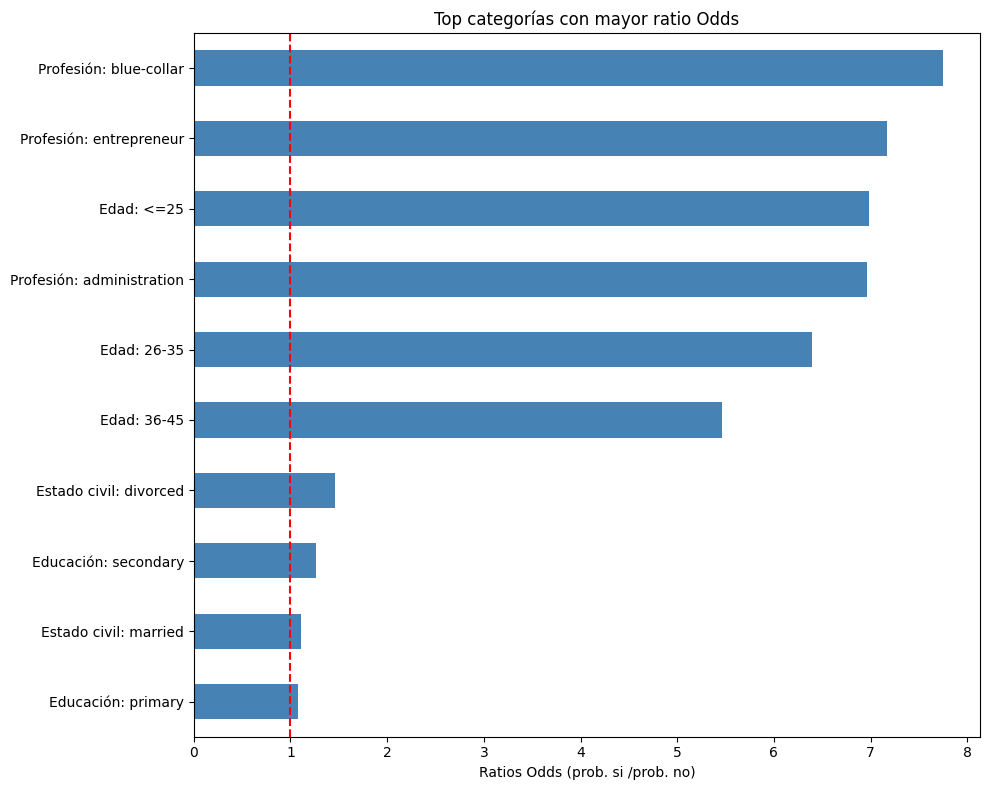

In [47]:
#Gráfico odds

# 1. Extraer Odds Ratios
odds = np.exp(resultado.params)

# 2. Filtrar por grupos
job_odds = odds[odds.index.str.startswith("job_")]
age_odds = odds[odds.index.str.startswith("age_group_")]
marital_odds = odds[odds.index.str.startswith("marital_")]
edu_odds = odds[odds.index.str.startswith("education_")]

# 3. Eliminar education_unknown
edu_odds = edu_odds[~edu_odds.index.str.contains("unknown")]

# 4. Seleccionar top 3 de cada grupo
top3_jobs = job_odds.sort_values(ascending=False).head(3)
top3_age = age_odds.sort_values(ascending=False).head(3)
top3_marital = marital_odds.sort_values(ascending=False).head(3)
top3_edu = edu_odds.sort_values(ascending=False).head(3)

# 5. Combinar todo
combined = pd.concat([top3_jobs, top3_age, top3_marital, top3_edu])

# 6. Limpiar nombres
combined.index = (
    combined.index
    .str.replace("job_", "Profesión: ")
    .str.replace("age_group_", "Edad: ")
    .str.replace("marital_", "Estado civil: ")
    .str.replace("education_", "Educación: ")
)
# Crear diccionario de reemplazo
rename_dict = {
    "Profesión: blue-collar": "Profesión: operario",
    "Profesión: entrepreneur": "Profesión: emprendedor",
    "Profesión: administration": "Profesión: administrativo",
    "Estado civil: divorced": "Estado civil: divorciado",
    "Estado civil: married": "Estado civil: casado",
    "Educación: primary": "Educación: primaria",
    "Educación: secondary": "Educación: secundaria"
}

# Aplicar renombrado a los índices
combined_renamed = combined.copy()
combined_renamed.index = combined_renamed.index.to_series().replace(rename_dict)

# 7. Graficar
plt.figure(figsize=(10,8))
combined.sort_values().plot(kind='barh', color='steelblue')

plt.title("Top categorías con mayor ratio Odds")
plt.xlabel("Ratios Odds (prob. si /prob. no)")
plt.axvline(1, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Cuántas veces aumentan (o disminuyen) los odds respecto a la categoría base.

Interpretación:

OR = 1 → no cambia nada

OR > 1 → aumenta la probabilidad

OR < 1 → disminuye la probabilidad

Ejemplos:

OR = 2 → el grupo tiene el doble de odds que la base

OR = 0.5 → el grupo tiene la mitad de odds que la base

OR = 7 → el grupo tiene 7 veces más odds que la base

        Logit Marginal Effects       
Dep. Variable:      multiproducto_bin
Method:                          dydx
At:                           overall
                         dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
age_group_<=25          0.3439      0.055      6.223      0.000       0.236       0.452
age_group_26-35         0.3283      0.051      6.500      0.000       0.229       0.427
age_group_36-45         0.3004      0.050      5.966      0.000       0.202       0.399
age_group_46-55         0.2531      0.050      5.026      0.000       0.154       0.352
age_group_56-65         0.2223      0.049      4.529      0.000       0.126       0.318
education_primary       0.0136      0.017      0.803      0.422      -0.020       0.047
education_secondary     0.0414      0.012      3.455      0.001       0.018       0.065
education_unknown      -0.0369      0.025     -1.464    

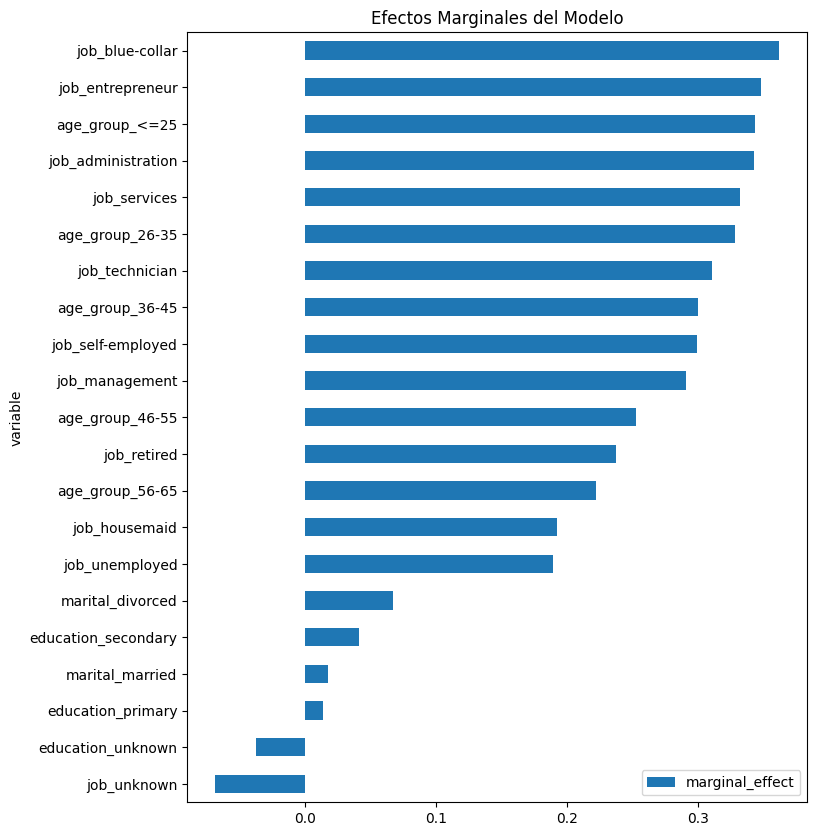

In [34]:
#Efectos marginales
mfx = resultado.get_margeff()
print(mfx.summary())

mfx_df = pd.DataFrame({
    'variable': mfx.summary_frame().index,
    'marginal_effect': mfx.margeff
})

mfx_df.sort_values('marginal_effect').plot(
    x='variable', y='marginal_effect', kind='barh', figsize=(8,10)
)
plt.title("Efectos Marginales del Modelo")
plt.show()

In [35]:
params = resultado.params
conf = resultado.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
print(np.exp(conf))

                         2.5%      97.5%  Odds Ratio
const                0.004244   0.018257    0.008803
age_group_<=25       3.781017  12.895202    6.982620
age_group_26-35      3.650124  11.201640    6.394323
age_group_36-45      3.124250   9.547475    5.461566
age_group_46-55      2.391599   7.301655    4.178831
age_group_56-65      2.038587   6.047298    3.511117
education_primary    0.895129   1.302644    1.079831
education_secondary  1.106345   1.443529    1.263741
education_unknown    0.613647   1.073388    0.811592
marital_married      0.991623   1.236113    1.107139
marital_divorced     1.249297   1.720333    1.466017
job_administration   4.357091  11.109980    6.957528
job_technician       3.642383   9.240887    5.801624
job_services         4.077910  10.528642    6.552469
job_management       3.231479   8.300473    5.179074
job_retired          2.224498   6.621364    3.837865
job_blue-collar      4.864421  12.328237    7.744013
job_unemployed       1.697559   5.004853    2.

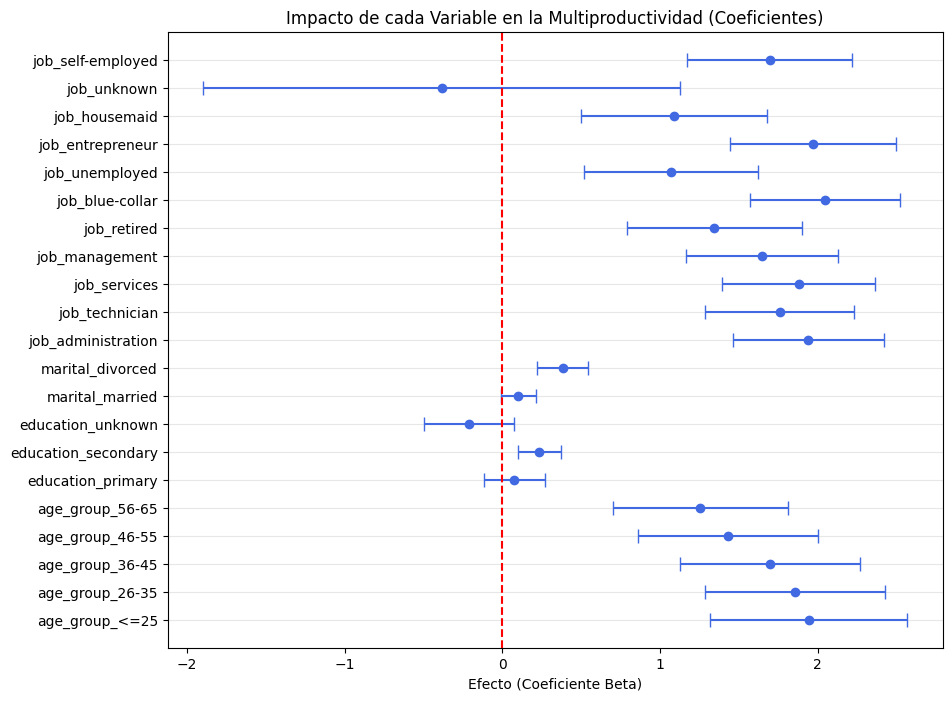

In [36]:
# Extraer coeficientes e intervalos de confianza
df_res = pd.DataFrame({
    'coef': resultado.params,
    'error': resultado.bse,
    'p_valor': resultado.pvalues
})
# Quitamos la constante para que no arruine la escala del gráfico
df_res = df_res.drop('const')

# Graficar
plt.figure(figsize=(10, 8))
plt.errorbar(df_res['coef'], df_res.index, xerr=2*df_res['error'], fmt='o', color='royalblue', capsize=5)
plt.axvline(x=0, color='red', linestyle='--') # Línea de neutralidad
plt.title('Impacto de cada Variable en la Multiproductividad (Coeficientes)')
plt.xlabel('Efecto (Coeficiente Beta)')
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\misab\AppData\Local\Temp\ipykernel_21572\781651245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_perfil, x='age_group', y='prob_predicha', palette='magma')


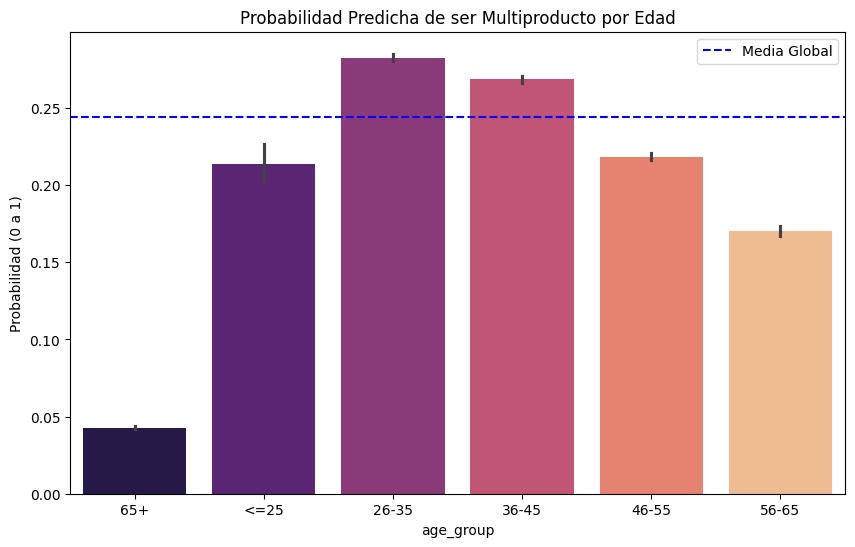

In [48]:
# Generar las probabilidades predichas del modelo
df_perfil['prob_predicha'] = resultado.predict(X_dummies)

# Graficar la probabilidad promedio por grupo de edad
plt.figure(figsize=(10, 6))
sns.barplot(data=df_perfil, x='age_group', y='prob_predicha', palette='magma')
plt.title('Probabilidad Predicha de ser Multiproducto por Edad')
plt.ylabel('Probabilidad (0 a 1)')
plt.axhline(df_perfil['multiproducto_bin'].mean(), color='blue', linestyle='--', label='Media Global')
plt.legend()
plt.show()

In [50]:
#Función para calcular probabilidades de perfiles:
def predict_profile(age_group=None, education=None, marital=None, job=None):
    # Crear fila vacía con todas las columnas del modelo
    row = {col: 0 for col in X_dummies.columns}
    
    # Intercepto
    if 'const' in row:
        row['const'] = 1

    # Activar dummies de edad
    if age_group is not None:
        col = f'age_group_{age_group}'
        if col in row:
            row[col] = 1

    # Activar dummies de educación
    if education is not None:
        col = f'education_{education}'
        if col in row:
            row[col] = 1

    # Activar dummies de estado civil
    if marital is not None:
        col = f'marital_{marital}'
        if col in row:
            row[col] = 1

    # Activar dummies de job
    if job is not None:
        col = f'job_{job}'
        if col in row:
            row[col] = 1

    # Convertir a DataFrame y predecir probabilidad
    df = pd.DataFrame([row])
    prob = resultado.predict(df)[0]

    return prob


In [54]:
probabilidad_perfil_1 = predict_profile(
    age_group="<=25",
    education="secondary",
    marital="divorced",
    job="blue-collar")

print(f"La probabilidad del perfil top 1 es del {round((probabilidad_perfil_1)*100, 2)}%.")

La probabilidad del perfil top 1 es del 46.86%.


In [55]:
probabilidad_perfil_2 = predict_profile(
    age_group="26-35",
    education="primary",
    marital="married",
    job="entrepreneur")

print(f"La probabilidad del perfil top 2 es del {round((probabilidad_perfil_2)*100, 2)}%.")

La probabilidad del perfil top 2 es del 32.53%.
